# CNN Digit Recognition

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("mnist_train.csv")

df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
X = df.drop(columns=['label'])
y = df['label']

In [4]:
X = X.values.reshape(-1,1,28,28)

In [6]:
X = X / 255.0

In [7]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.long)

In [8]:
class DigitDataset(Dataset):

    def __init__(self,X,y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self,index):
        return self.X[index], self.y[index]

In [9]:
dataset = DigitDataset(X_tensor,y_tensor)

dataloader = DataLoader(dataset,
                        batch_size=64,
                        shuffle=True)

In [10]:
class CNNModel(nn.Module):

    def __init__(self):
        super().__init__()

        # Convolution layer 1
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Convolution layer 2
        self.conv2 = nn.Conv2d(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        # Fully connected layer
        self.fc1 = nn.Linear(32 * 7 * 7, 128)

        self.fc2 = nn.Linear(128, 10)

        self.relu = nn.ReLU()

    def forward(self, x):

        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = torch.flatten(x, start_dim=1)

        x = self.fc1(x)
        x = self.relu(x)

        x = self.fc2(x)

        return x

In [11]:
model = CNNModel()

In [12]:
print(model)

CNNModel(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


In [13]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [14]:
epochs = 5

for epoch in range(epochs):

    model.train()

    for images, labels in dataloader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 1/5, Loss: 0.0193
Epoch 2/5, Loss: 0.0179
Epoch 3/5, Loss: 0.0215
Epoch 4/5, Loss: 0.1071
Epoch 5/5, Loss: 0.0053


In [15]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in dataloader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 99.55%


In [16]:
model.eval()

with torch.no_grad():

    images, labels = next(iter(dataloader))

    outputs = model(images)

    _, predicted = torch.max(outputs, 1)

for i in range(10):
    print("Predicted:", predicted[i].item(),
          "Actual:", labels[i].item())

Predicted: 0 Actual: 0
Predicted: 8 Actual: 8
Predicted: 8 Actual: 8
Predicted: 6 Actual: 6
Predicted: 5 Actual: 5
Predicted: 6 Actual: 6
Predicted: 1 Actual: 1
Predicted: 9 Actual: 9
Predicted: 5 Actual: 5
Predicted: 3 Actual: 3


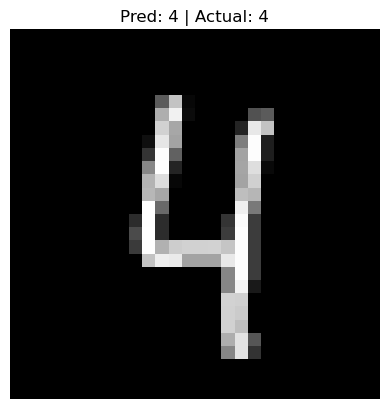

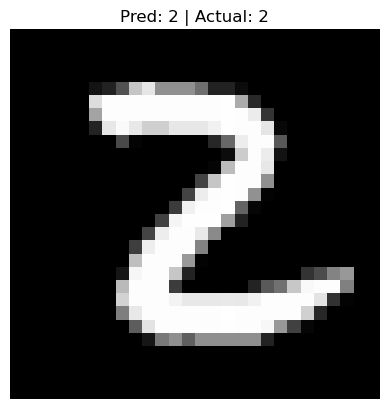

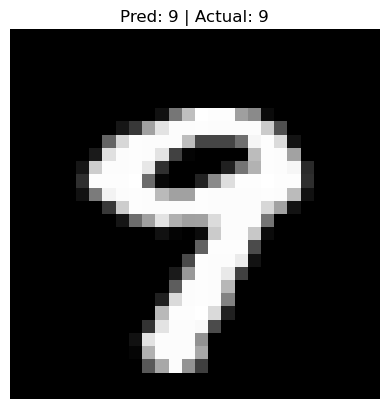

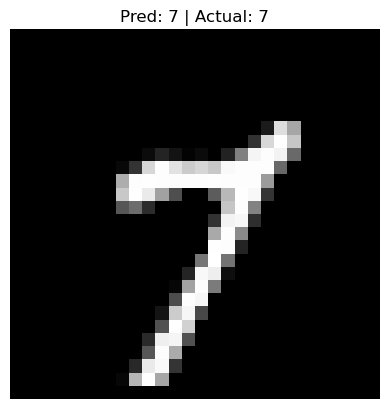

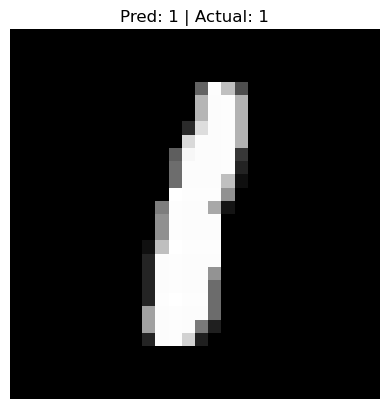

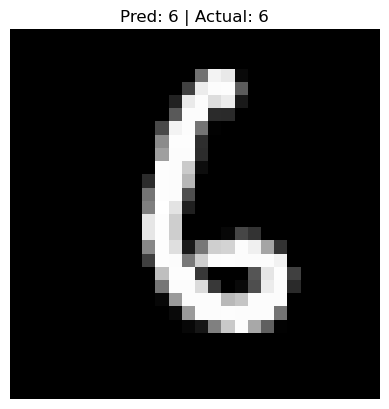

In [17]:
import matplotlib.pyplot as plt

images, labels = next(iter(dataloader))

with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

for i in range(6):

    plt.imshow(images[i].squeeze(), cmap="gray")

    plt.title(f"Pred: {predicted[i].item()} | Actual: {labels[i].item()}")

    plt.axis("off")

    plt.show()